# ARMA Baseline for ECG Anomaly Detection

This notebook runs the first complete anomaly detection experiment.

Pipeline:
1. load MIT-BIH records;
2. segment ECG beats using annotations;
3. split train/test by record;
4. fit an ARMA-based anomaly threshold on normal training beats;
5. evaluate predictions on test beats.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    read_record_names,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import ARMAModel

## Load a Small Subset

ARMA is computationally expensive here because we fit a small model for each beat. For the first run, we use only a few records to validate the pipeline.

In [2]:
N_RECORDS = 5

# Paced records are excluded via config.DROP_PACED (see read_record_names).
record_names = read_record_names(config.MIT_BIH_PATH)[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '103', '105', '106']


## Create Beat Dataset

Each row is one ECG beat window. The label belongs to the whole beat segment, not to a single sample.

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10818, 7)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     10211
anomaly      607
Name: count, dtype: int64

symbol
N    10211
V      562
A       38
Q        7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values)
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10818, 180)
y shape: (10818,)


## Train/Test Split by Record

Splitting by record avoids putting beats from the same patient/record in both train and test.

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '103', '105']
Test records: ['106']
Train shape: (8791, 180)
Test shape: (2027, 180)
Train labels:


normal     8704
anomaly      87
Name: count, dtype: int64

Test labels:


normal     1507
anomaly     520
Name: count, dtype: int64

## Fit ARMA Threshold

The ARMA score is one Mean Squared Error value per beat. The threshold is estimated from normal training beats.

In [6]:
MAX_TRAIN_NORMAL = 150
MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

X_train_normal = split["X_train"][split["y_train"] == 0]
X_train_normal = X_train_normal[:MAX_TRAIN_NORMAL]

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_small = split["X_test"][test_indices]
y_test_small = split["y_test"][test_indices]

arma = ARMAModel(p=1, d=0, q=1, threshold_percentile=95)
arma.fit(X_train_normal)

print("Training normal beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_small))
display(pd.Series(y_test_small).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("Threshold:", arma.threshold)

Training normal beats used: 150
Test beats used: 300


anomaly    150
normal     150
Name: count, dtype: int64

Threshold: 0.0007765653322197417


## Evaluate

In [7]:
scores = arma.anomaly_score(X_test_small)
y_pred = arma.predict(X_test_small)

results = evaluate_anomaly_detection(y_test_small, y_pred, scores)
results

{'confusion_matrix': [[131, 19], [139, 11]],
 'precision': 0.36666666666666664,
 'recall': 0.07333333333333333,
 'f1': 0.12222222222222222,
 'roc_auc': 0.11146666666666667,
 'pr_auc': 0.35470481260906445}

### Metric Interpretation

On this subset the ARMA detector performs **poorly**: at the 95th-percentile threshold both precision and recall are low, and the ROC-AUC is **below 0.5**. An AUC below chance means the ARMA reconstruction error is *anti-correlated* with the anomaly label here — anomalous beats tend to get a *lower* error than normal ones.

A plausible reason: the anomalies in this test record are mostly wide, smooth ventricular beats, which a low-order ARMA(1, 0, 1) can fit *more* easily than a normal beat with its sharp QRS spike. So the score ends up favoring the anomalies.

This is a real limitation of ARMA as an anomaly score, not just a tuning issue: no threshold can fix a score that ranks the classes the wrong way (the AUC is the same at every threshold).

## Threshold Sensitivity

The threshold controls the trade-off between false positives and false negatives. In a medical screening context, a lower threshold may be preferable if missing an anomaly is considered more costly than triggering an additional check.

In [8]:
threshold_results = []
train_scores = arma.anomaly_score(X_train_normal)

for percentile in [95, 90, 85, 80, 75]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_small, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95,0.000777,0.366667,0.073333,0.122222,0.111467,0.354705
1,90,0.000765,0.305556,0.073333,0.118280,0.111467,0.354705
2,85,0.000752,0.292683,0.080000,0.125654,0.111467,0.354705
3,80,0.000745,0.292683,0.080000,0.125654,0.111467,0.354705
4,75,0.000733,0.279070,0.080000,0.124352,0.111467,0.354705


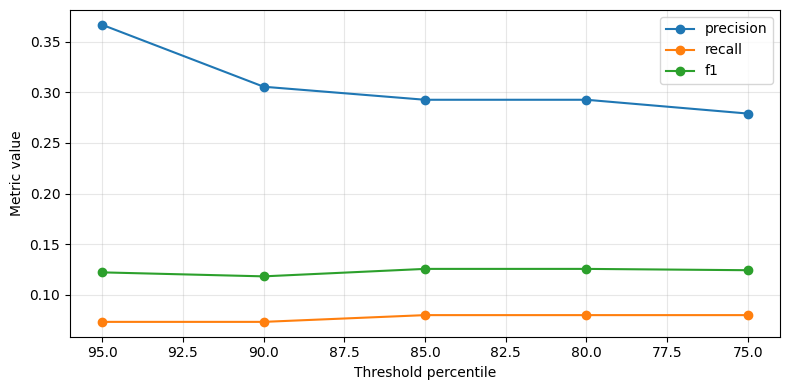

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

Because the ARMA score does not separate the two classes on this subset (AUC below chance), moving the threshold percentile does not help: precision and recall stay low at every operating point, and the AUC is threshold-independent.

This is different from a model that ranks anomalies correctly but only needs a better threshold. Here the problem is the score itself, not the operating point.

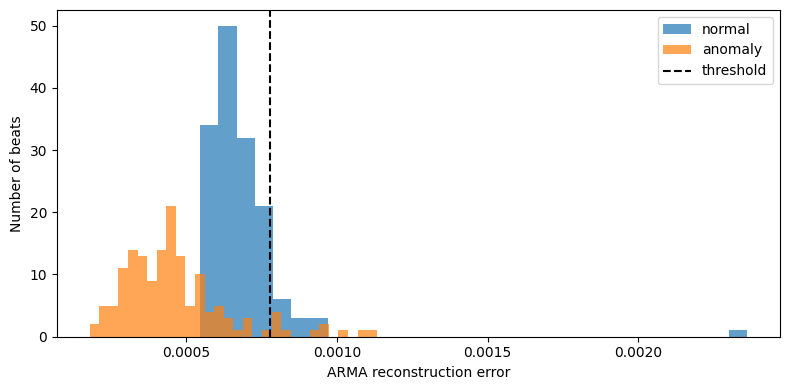

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_small == 0], bins=30, alpha=0.7, label="normal")
plt.hist(scores[y_test_small == 1], bins=30, alpha=0.7, label="anomaly")
plt.axvline(arma.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("ARMA reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

- ARMA is used as a classical time-series baseline, directly linked to the course theory: each ECG beat is treated as a short time series and scored by its average squared reconstruction/prediction error.
- On this subset the score is **anti-correlated** with the anomalies (AUC below chance), plausibly because wide ventricular beats are easier for a low-order ARMA to fit than normal beats.
- The threshold is learned from normal training beats, but no threshold can rescue a score that ranks the classes the wrong way.
- **Caveat:** the test set here is a single record (106), so these numbers are volatile and preliminary. They validate the pipeline; the full-dataset experiment is needed before drawing conclusions about ARMA.
- Overall, ARMA mainly serves as a theoretical baseline; later models handle ECG morphology more naturally.